<a href="https://colab.research.google.com/github/ravindu374/Image-processing-and-Machine-vision/blob/main/Assignment2_EN3160.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Assignment 2**

In [91]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import math
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Question 1

In [92]:
file_path = '/content/drive/MyDrive/openCV/the_berry_farms_sunflower_field.jpeg'
img = cv.imread(file_path,cv.IMREAD_REDUCED_COLOR_4)
assert img is not None
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)


In [104]:
# Select range of sigma
sigma_values = np.linspace(1,2, 9)
# Threhsold for blob detection
threshold = 0.38

# Store responses of each scale
blob_responses = []

for sigma in sigma_values:
    print(f"Processing scale with sigma = {sigma}")

    # Apply Gaussian blur
    gaussian_blur = cv.GaussianBlur(gray, (0, 0), sigma)
    # Compute Laplacian of Gaussian (LoG)
    laplacian = cv.Laplacian(gaussian_blur, cv.CV_64F)
    # Get absolute value
    blob_response = np.abs(laplacian)

    # Threshold the response and get contours
    mask = blob_response > threshold * blob_response.max()
    contours, _ = cv.findContours(mask.astype(np.uint8), cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

    # Draw contours as circles
    for contour in contours:
        if len(contour) >= 5:
            # Get the center and radius of the enclosing circle from contour
            (center_x, center_y), radius = cv.minEnclosingCircle(contour)
            # Convert to integers
            center = (int(center_x), int(center_y))
            radius = int(radius)
            blob_responses.append((center, radius, sigma))
#print(blob_responses)


Processing scale with sigma = 1.0
Processing scale with sigma = 1.125
Processing scale with sigma = 1.25
Processing scale with sigma = 1.375
Processing scale with sigma = 1.5
Processing scale with sigma = 1.625
Processing scale with sigma = 1.75
Processing scale with sigma = 1.875
Processing scale with sigma = 2.0


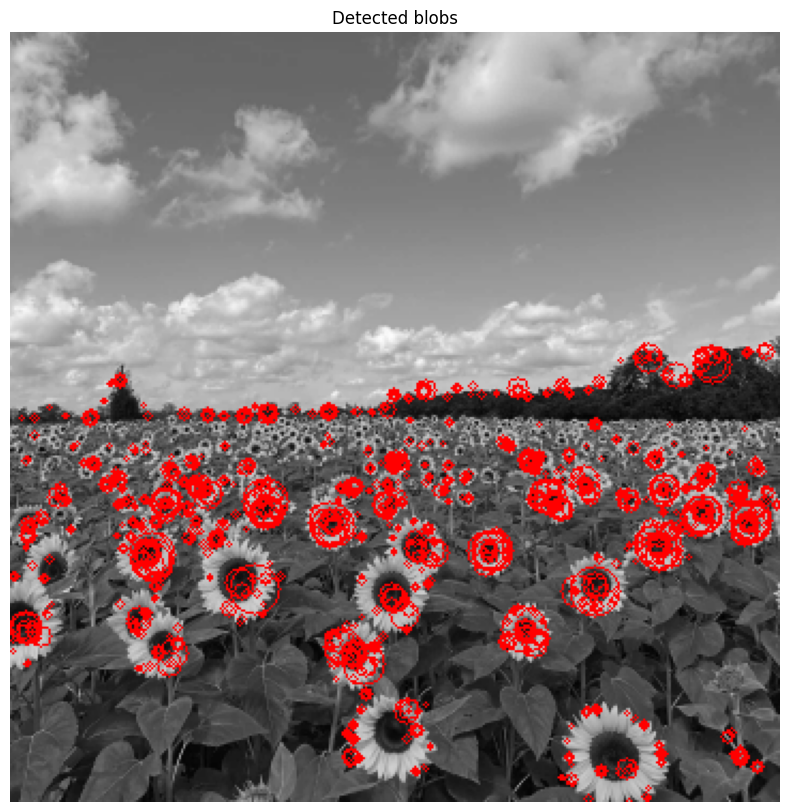

In [105]:
# Draw all detected circles with the specified line thickness
output = cv.cvtColor(gray, cv.COLOR_GRAY2BGR)
for blob in blob_responses:
    center, radius, _ = blob
    cv.circle(output, center, radius, (0, 0, 255), 1)

# Display the grayscale image with detected circles
plt.figure(figsize=(10, 10))
plt.imshow(cv.cvtColor(output, cv.COLOR_BGR2RGB), cmap='gray')
plt.axis('off')
plt.title('Detected blobs')
plt.show()

In [106]:
# Get largest circle
blobs_sorted = sorted(blob_responses, key=lambda x: x[1], reverse=True)
largest_blob = blobs_sorted[0]
center, radius, sigma = largest_blob

# Print largest circle details
print(f"Largest blob at : {center} with radius {radius} and sigma {sigma}")

Largest blob at : (273, 261) with radius 12 and sigma 2.0


0.71,0.99,1.27,1.56,1.84,2.12,2.40,2.69,2.97,3.25,3.54,3.82,4.10,4.38,4.67,4.95,5.23,5.52,5.80,6.08,6.36,6.65,6.93,7.21,7.50,

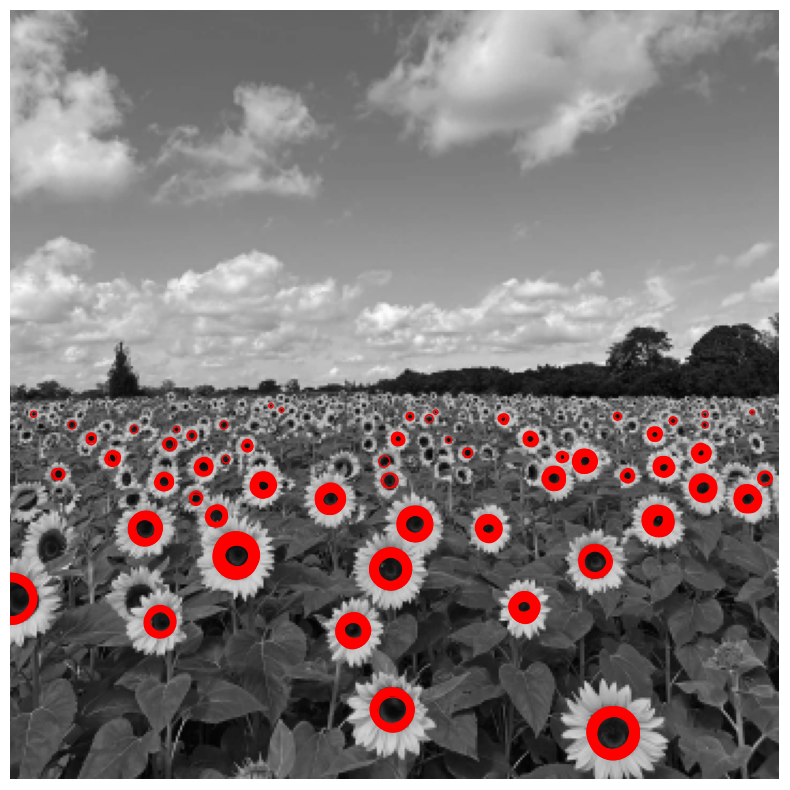

In [123]:
import matplotlib.colors as mcolors

# Load the image and convert it to grayscale
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY) / 255

# Display the grayscale image with detected circles
plt.figure(figsize=(10, 10), frameon=False)
plt.imshow(gray, cmap='gray')
plt.axis('off')

# Get the current axes object
ax = plt.gca()

patches = []
labels = []

# Detect blobs at different sigma values
for r in np.arange(1,11,0.4):
    sigma = r / 1.414
    print(f"{sigma:.2f}", end=",")
    hw = round(3 * sigma)  # Half width of the kernel
    X, Y = np.meshgrid(np.arange(-hw, hw + 1, 1), np.arange(-hw, hw + 1, 1))

    # Calculate Laplacian of Gaussian (LoG) filter
    LOG = ((X**2 + Y**2) / (2 * sigma**2) - 1) * np.exp(-(X**2 + Y**2) / (2 * sigma**2)) / (np.pi * sigma**4)

    # Scale the filter and apply it to the image
    LOG = sigma**2 * LOG
    img1_log = np.square(cv.filter2D(gray, -1, LOG))

    # Detect maxima manually
    coordinates = []
    (H, W) = img1_log.shape
    k = 1  # Neighborhood size
    threshold = 0.1  # Threshold for maxima detection
    for i in range(k, H - k):
        for j in range(k, W - k):
            slice_img = img1_log[i - k:i + k + 1, j - k:j + k + 1]
            if np.max(slice_img) >= threshold:
                # Get coordinates of the maximum point
                x, y = np.unravel_index(slice_img.argmax(), slice_img.shape)
                coordinates.append((i + x - k, j + y - k))
    coordinates = set(coordinates)

    # Plot circles around detected blobs
    for x, y in coordinates:
        c = plt.Circle((y, x), sigma * 1.414, color='r', linewidth=1, fill=False)
        ax.add_patch(c)
    patches.append(c)
    ax.plot()

ax.set_xlim([0, img.shape[1]])
ax.set_ylim([img.shape[0], 0])

# Add legend and title
plt.axis('off')
plt.show()